In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import time
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torchvision import datasets, transforms, models
from torchvision.models import Inception_V3_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
def prepare_cub_dataset(val_ratio=0.1):
    base = Path("/content/drive/MyDrive/Deep_Learning/Coursework/CUB_200_2011")
    images_path = base / "images"

    images_df = pd.read_csv(base / "images.txt", sep=" ", header=None,
                            names=["img_id", "filepath"])
    labels_df = pd.read_csv(base / "image_class_labels.txt", sep=" ", header=None,
                            names=["img_id", "class_id"])
    split_df = pd.read_csv(base / "train_test_split.txt", sep=" ", header=None,
                           names=["img_id", "is_train"])

    data = images_df.merge(labels_df).merge(split_df)

    train_df = data[data.is_train == 1]
    test_df  = data[data.is_train == 0]

    full_dataset = datasets.ImageFolder(images_path)

    path_to_idx = {
        str(Path(p).relative_to(images_path)): i
        for i, (p, _) in enumerate(full_dataset.samples)
    }

    train_indices_all = [path_to_idx[p] for p in train_df.filepath]

    train_idx, val_idx = train_test_split(
        train_indices_all,
        test_size=val_ratio,
        stratify=train_df.class_id,
        random_state=SEED
    )

    test_indices = [path_to_idx[p] for p in test_df.filepath]

    return (
        Subset(full_dataset, train_idx),
        Subset(full_dataset, val_idx),
        Subset(full_dataset, test_indices))

In [ ]:
class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        x, y = self.subset[idx]
        if self.transform:
            x = self.transform(x)
        return x, y


def create_dataloaders(train_ds, val_ds, test_ds, batch_size=32):

    train_tfms = transforms.Compose([
        transforms.Resize(320),
        transforms.RandomResizedCrop(299, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(0.2,0.2,0.2,0.1),
        transforms.RandomRotation(15),
        transforms.RandomGrayscale(p=0.1),
        transforms.RandomPerspective(0.2, p=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],
                             [0.229,0.224,0.225])
    ])

    val_tfms = transforms.Compose([
        transforms.Resize(320),
        transforms.CenterCrop(299),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],
                             [0.229,0.224,0.225])
    ])

    train_ds = TransformSubset(train_ds, train_tfms)
    val_ds   = TransformSubset(val_ds, val_tfms)
    test_ds  = TransformSubset(test_ds, val_tfms)

    # Weighted sampler
    targets = [train_ds.subset.dataset.samples[i][1]
               for i in train_ds.subset.indices]

    class_counts = np.bincount(targets)
    class_weights = 1.0 / class_counts
    sample_weights = [class_weights[t] for t in targets]

    sampler = WeightedRandomSampler(
        sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )

    pin = device.type == "cuda"

    loaders = {
        "train": DataLoader(train_ds, batch_size=batch_size,
                            sampler=sampler, num_workers=4,
                            pin_memory=pin),

        "val": DataLoader(val_ds, batch_size=batch_size,
                          shuffle=False, num_workers=4,
                          pin_memory=pin),

        "test": DataLoader(test_ds, batch_size=batch_size,
                           shuffle=False, num_workers=4,
                           pin_memory=pin)
    }

    sizes = {k: len(v.dataset) for k,v in loaders.items()}
    class_names = train_ds.subset.dataset.classes

    return loaders, sizes, class_names


In [ ]:
def build_inception(num_classes, aux_logits=True):
    model = models.inception_v3(
        weights=Inception_V3_Weights.DEFAULT,
        aux_logits=aux_logits)

    model.fc = nn.Linear(model.fc.in_features, num_classes)

    if aux_logits:
        model.AuxLogits.fc = nn.Linear(
            model.AuxLogits.fc.in_features,
            num_classes)

    return model

#custom model definition to be inserted here
#

In [ ]:
def freeze_except_linear(model):
    for p in model.parameters():
        p.requires_grad = False
    for m in model.modules():
        if isinstance(m, nn.Linear):
            for p in m.parameters():
                p.requires_grad = True

def forward_logits(model, x):
    out = model(x)
    if hasattr(out, "logits"):
        return out.logits, getattr(out, "aux_logits", None)
    if isinstance(out, tuple):
        return out[0], (out[1] if len(out) > 1 else None)
    return out, None

In [ ]:
def train_model(model, loaders, sizes,
                total_epochs=25,
                phase1_epochs=5,
                patience=5,
                save_path="best_model.pth"):

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    scaler = torch.amp.GradScaler()

    history = {"train_loss":[], "val_loss":[],
               "train_acc":[], "val_acc":[]}

    best_acc = 0
    early_stop = 0

    # ========================
    # PHASE 1: Train classifier
    # ========================
    for name, param in model.named_parameters():
        if "fc" not in name and "AuxLogits" not in name:
            param.requires_grad = False

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-3,
        weight_decay=1e-4
    )

    print("\n===== Phase 1 =====")
    for epoch in range(phase1_epochs):
        model.train()
        running_corrects = 0
        running_loss = 0

        for x,y in loaders["train"]:
            x,y = x.to(device), y.to(device)
            optimizer.zero_grad()

            with torch.amp.autocast(device_type=device.type):
                outputs = model(x)
                loss = (criterion(outputs.logits, y) +
                        0.4*criterion(outputs.aux_logits, y))
                preds = outputs.logits.argmax(1)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()*x.size(0)
            running_corrects += (preds==y).sum().item()

        epoch_acc = running_corrects / sizes["train"]
        print(f"Epoch {epoch+1}/{phase1_epochs} - Acc: {epoch_acc:.4f}")

    # ========================
    # PHASE 2: Fine-tuning
    # ========================
    for param in model.parameters():
        param.requires_grad = True

    model.aux_logits = False

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=total_epochs-phase1_epochs)

    print("\n===== Phase 2 =====")

    for epoch in range(total_epochs-phase1_epochs):

        for phase in ["train","val"]:
            model.train() if phase=="train" else model.eval()

            running_loss = 0
            running_corrects = 0

            for x,y in loaders[phase]:
                x,y = x.to(device), y.to(device)
                optimizer.zero_grad()

                with torch.amp.autocast(device_type=device.type):
                    outputs = model(x)
                    loss = criterion(outputs, y)
                    preds = outputs.argmax(1)

                if phase=="train":
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()

                running_loss += loss.item()*x.size(0)
                running_corrects += (preds==y).sum().item()

            epoch_loss = running_loss / sizes[phase]
            epoch_acc  = running_corrects / sizes[phase]

            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)

            if phase=="val":
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    early_stop = 0
                    torch.save(model.state_dict(), save_path)
                else:
                    early_stop += 1

        scheduler.step()
        print(f"Epoch {epoch+1} - Val Acc: {history['val_acc'][-1]:.4f}")

        if early_stop >= patience:
            print("Early stopping triggered.")
            break

    model.load_state_dict(torch.load(save_path))
    return model, history

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,)


def evaluate(model, dataloader, class_names, device, plot_cm=True):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            predictions = outputs.argmax(dim=1).cpu()

            all_preds.append(predictions)
            all_labels.append(targets)

    # Concatenate tensors once
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    # ===== Metrics =====
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    print("\n===== FINAL TEST RESULTS =====")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f} (macro)")
    print(f"Recall   : {recall:.4f} (macro)")
    print(f"F1-score : {f1:.4f} (macro)")

    print("\nDetailed Classification Report:\n")
    print(classification_report(all_labels, all_preds,
                                target_names=class_names,
                                digits=4))

    # ===== Confusion Matrix =====
    if plot_cm:
        cm = confusion_matrix(all_labels, all_preds)

        plt.figure(figsize=(12, 10))
        sns.heatmap(cm, cmap="Blues", square=True, cbar=True)
        plt.title("Confusion Matrix")
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.tight_layout()
        plt.show()

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

In [ ]:
start = time.time()

train_ds, val_ds, test_ds = prepare_cub_dataset()
loaders, sizes, class_names = create_dataloaders(
    train_ds, val_ds, test_ds, batch_size=32)

model = build_inception(len(class_names), aux_logits=True).to(device)

model, history = train_model(
    model,
    loaders,
    sizes,
    total_epochs=20,
    phase1_epochs=5)

print(f"\nTotal Time: {(time.time()-start)/60:.2f} minutes")


===== Phase 1 =====
Epoch 1/5 - Acc: 0.1114
Epoch 2/5 - Acc: 0.2790
Epoch 3/5 - Acc: 0.3806
Epoch 4/5 - Acc: 0.4372
Epoch 5/5 - Acc: 0.4855

===== Phase 2 =====
Epoch 1 - Val Acc: 0.6633
Epoch 2 - Val Acc: 0.6867
Epoch 3 - Val Acc: 0.7167
Epoch 4 - Val Acc: 0.7200
Epoch 5 - Val Acc: 0.7367
Epoch 6 - Val Acc: 0.7500
Epoch 7 - Val Acc: 0.7350
Epoch 8 - Val Acc: 0.7350
Epoch 9 - Val Acc: 0.7483
Epoch 10 - Val Acc: 0.7550
Epoch 11 - Val Acc: 0.7717
Epoch 12 - Val Acc: 0.7633
Epoch 13 - Val Acc: 0.7533
Epoch 14 - Val Acc: 0.7633
Epoch 15 - Val Acc: 0.7717
Epoch 16 - Val Acc: 0.7683
Early stopping triggered.

Total Time: 12.39 minutes


In [ ]:
# Path where you want to save the model
save_dir = "/content/drive/MyDrive/Deep_Learning/Coursework/saved_models"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, "inception_cub_best.pth")

# Save model weights
torch.save(model.state_dict(), save_path)

print(f"Model successfully saved to:\n{save_path}")

Model successfully saved to:
/content/drive/MyDrive/Deep_Learning/Coursework/saved_models/inception_cub_best.pth



===== TEST EVALUATION (Loaded Model) =====

===== FINAL TEST RESULTS =====
Accuracy : 0.7767
Precision: 0.7827 (macro)
Recall   : 0.7784 (macro)
F1-score : 0.7748 (macro)

Detailed Classification Report:

                                    precision    recall  f1-score   support

        001.Black_footed_Albatross     0.9259    0.8333    0.8772        30
              002.Laysan_Albatross     0.8333    0.8333    0.8333        30
               003.Sooty_Albatross     0.7297    0.9643    0.8308        28
             004.Groove_billed_Ani     0.8667    0.8667    0.8667        30
                005.Crested_Auklet     0.7333    0.7857    0.7586        14
                  006.Least_Auklet     0.9091    0.9091    0.9091        11
               007.Parakeet_Auklet     0.9200    1.0000    0.9583        23
             008.Rhinoceros_Auklet     0.7273    0.8889    0.8000        18
              009.Brewer_Blackbird     0.6429    0.6207    0.6316        29
          010.Red_winged_Blackbir

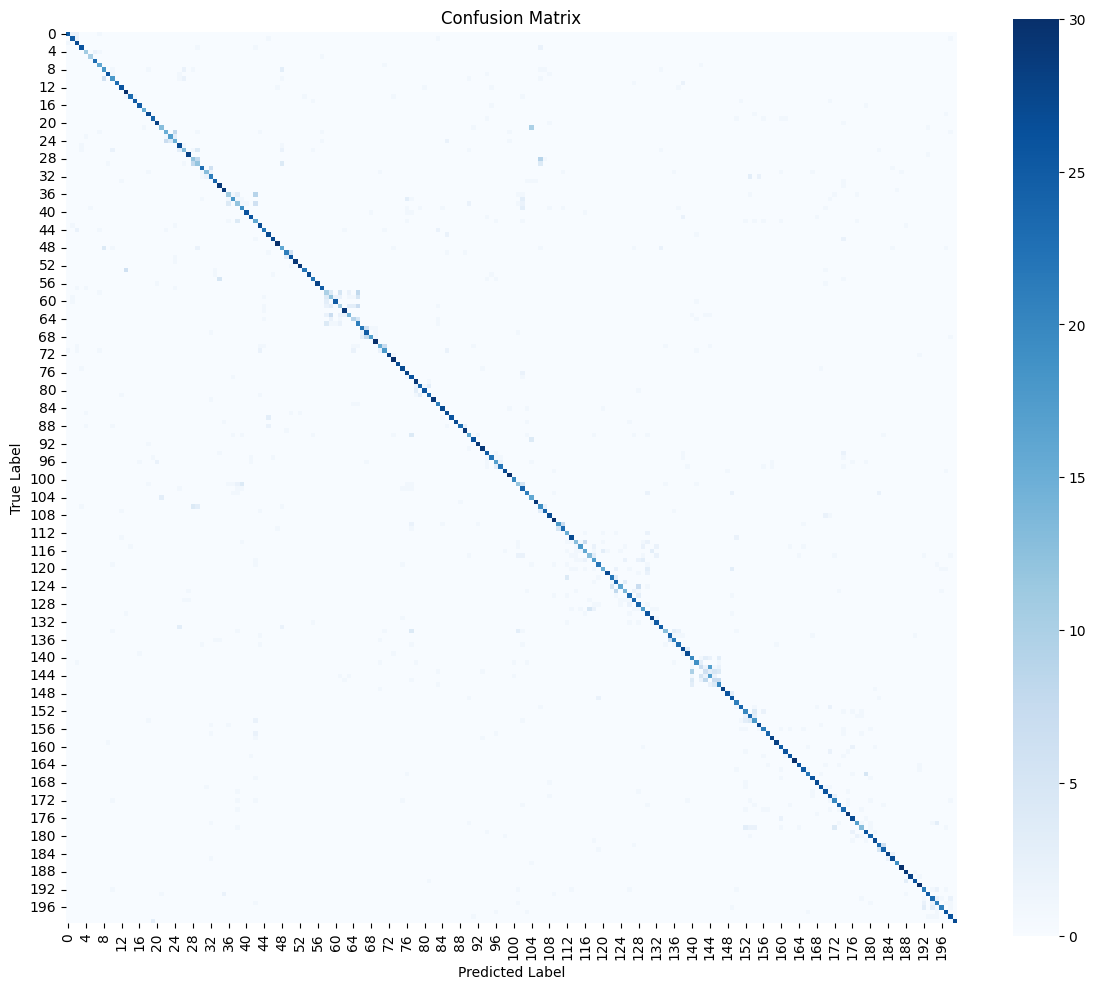

In [ ]:
print("\n===== TEST EVALUATION (Loaded Model) =====")

load_path = "/content/drive/MyDrive/Deep_Learning/Coursework/saved_models/inception_cub_best.pth"

model = build_inception(len(class_names), aux_logits=True).to(device)
model.load_state_dict(torch.load(load_path, map_location=device))
model.to(device)

metrics = evaluate(
    model=model,
    dataloader=loaders["test"],
    class_names=class_names,
    device=device,
    plot_cm=True,)

In [ ]:
from typing import Tuple, List
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,)

class ImageTxtDataset(Dataset):
    """
    Dataset structure:

    root/
        images/
            img1.jpg
            img2.jpg
        labels.txt

    labels.txt format:
        filename label
    """

    def __init__(self, root: str | Path, transform=None):
        self.root = Path(root)
        self.image_dir = self.root / "images"
        self.label_file = self.root / "labels.txt"
        self.transform = transform

        if not self.image_dir.exists():
            raise FileNotFoundError(f"Missing directory: {self.image_dir}")

        if not self.label_file.exists():
            raise FileNotFoundError(f"Missing file: {self.label_file}")

        self.samples = self._load_samples()

    def _load_samples(self) -> List[Tuple[Path, int]]:
        lines = self.label_file.read_text().strip().splitlines()

        entries = [line.split() for line in lines]
        if not all(len(entry) == 2 for entry in entries):
            raise ValueError("Each line in labels.txt must contain: <filename> <label>")

        filenames, labels = zip(*entries)

        # Determine if labels are numeric or string
        if all(label.isdigit() for label in labels):
            labels = [int(label) for label in labels]
        else:
            classes = sorted(set(labels))
            class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
            labels = [class_to_idx[label] for label in labels]

        samples = [
            (self.image_dir / fname, label)
            for fname, label in zip(filenames, labels)
        ]

        return samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


def evaluate_new_dataset(
    model,
    data_dir,
    device,
    batch_size=32,
    num_workers=4,
    image_size=299,
    resize_size=320,
):
    transform = transforms.Compose([
        transforms.Resize(resize_size),
        transforms.CenterCrop(image_size),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ])

    dataset = ImageTxtDataset(data_dir, transform=transform)

    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=device.type == "cuda",
    )

    model = model.to(device).eval()

    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            preds = model(inputs).argmax(dim=1)

            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(targets.cpu().tolist())

    metrics = {
        "accuracy": accuracy_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds, average="macro", zero_division=0),
        "recall": recall_score(all_labels, all_preds, average="macro", zero_division=0),
        "f1": f1_score(all_labels, all_preds, average="macro", zero_division=0),
    }

    print("\n===== NEW DATASET RESULTS =====")
    for k, v in metrics.items():
        print(f"{k.capitalize():<10}: {v:.4f}")

    print("\nClassification Report:\n")
    print(classification_report(all_labels, all_preds, digits=4))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return metrics


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = build_inception(len(class_names), aux_logits=True)
model.load_state_dict(torch.load(load_path, map_location=device))

metrics = evaluate_new_dataset(
    model=model,
    data_dir="data/new_test_dataset", #to be modified accordingly
    device=device,
    batch_size=32,)

print(metrics)